In [1]:
import gcinfo

gcinfo.list_resources(gcinfo.search_datasets(query='title:"Refugee Protection Division (RPD) Decisions"')["results"][0])


=== Refugee Protection Division (RPD) Decisions ===
ID: 6e47f705-71ed-41f0-8fd5-d1a8508a3b63
Org: Immigration and Refugee Board of Canada | Commission de l'immigration et du statut de réfugié du Canada
Notes: The Refugee Protection Division (RPD) of the Immigration and Refugee Board of Canada (IRB) hears and decides claims for refugee protection made in Canada. This dataset includes information on decision...
Citation: Immigration and Refugee Board of Canada. Refugee Protection Division (RPD) Decisions
  [XLSX    ] Refugee Protection Division (RPD) Decisions - Data Dictionary
           https://www.canada.ca/content/dam/irb-cisr/documents/RPD-Open-Data-Dictionary-July2018-eng.xlsx
  [XLSX    ] Refugee Protection Division Decisions 2020 Q4
           /data/dataset/6e47f705-71ed-41f0-8fd5-d1a8508a3b63/resource/072273f6-bac1-4e3c-92be-1a1411f63913/download/qr7-rpd-open-data-2020-q4-fra-revised.xlsx
  [CSV     ] Refugee Protection Division Decisions 2021 Q4
           /data/dataset/6e47f7

In [2]:
df = gcinfo.download_csv("https://open.canada.ca/data/dataset/6e47f705-71ed-41f0-8fd5-d1a8508a3b63/resource/ca03db72-81ad-4d2a-853f-ac5616cacf1a/download/qr7-rpd-open-data-2026-q2-fra.csv")

Using cached file: cache\qr7-rpd-open-data-2026-q2-fra.csv


In [3]:
df_2026 = df[df["Année"] == 2026]
df_2026

,Pays de persécution,Année,Résultats,Total
39,Afghanistan,2026,Positive,230
40,Afghanistan,2026,Négative,27
41,Afghanistan,2026,Autre,58
79,Afrique du Sud,2026,Positive,37
80,Afrique du Sud,2026,Négative,21
...,...,...,...,...
5787,Zimbabwe,2026,Positive,81
5788,Zimbabwe,2026,Négative,--
5789,Zimbabwe,2026,Autre,--
5809,Inconnu,2026,Négative,--


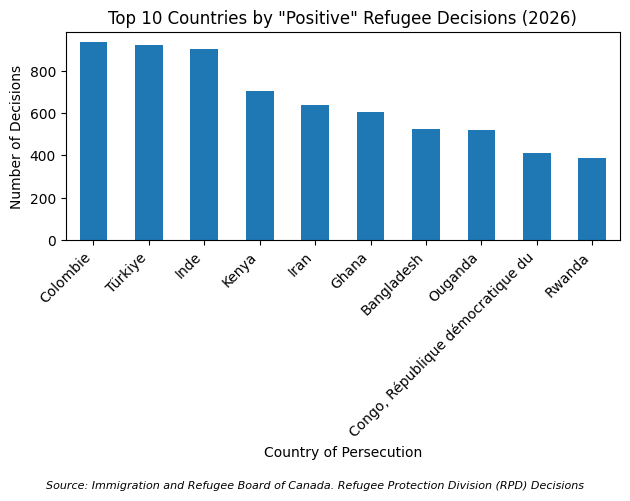

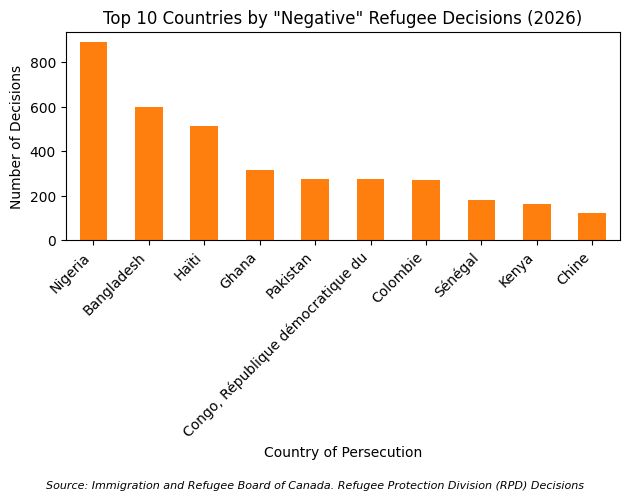

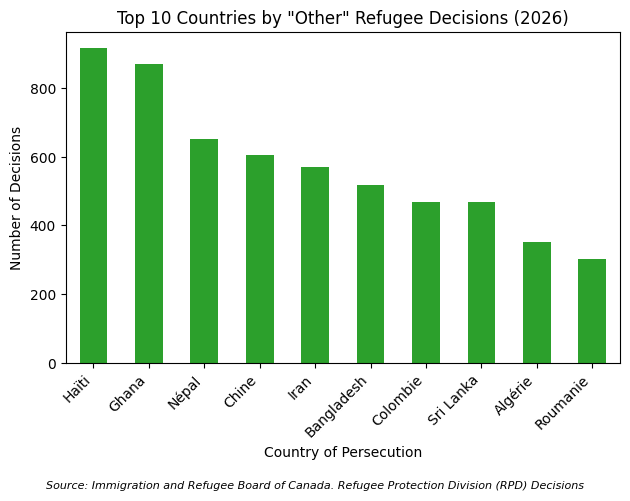

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Assumes df_2026 already exists with columns:
# Pays de persécution, Année, Résultats, Total

df_plot = df_2026.copy()
df_plot["Total"] = pd.to_numeric(df_plot["Total"], errors="coerce").fillna(0)

pivot = df_plot.pivot_table(
    index="Pays de persécution",
    columns="Résultats",
    values="Total",
    aggfunc="sum",
    fill_value=0
)

# Ensure the three result columns exist
for col in ["Positive", "Négative", "Autre"]:
    if col not in pivot.columns:
        pivot[col] = 0

# ---------- Plot 1: Top 10 by Positive ----------
top_positive = pivot["Positive"].sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_positive.plot(kind="bar", ax=ax, color="C0")

ax.set_title('Top 10 Countries by "Positive" Refugee Decisions (2026)')
ax.set_xlabel("Country of Persecution")
ax.set_ylabel("Number of Decisions")

plt.figtext(
    0.5, -0.03,
    "Source: Immigration and Refugee Board of Canada. Refugee Protection Division (RPD) Decisions",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.subplots_adjust(bottom=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------- Plot 2: Top 10 by Négative ----------
top_negative = pivot["Négative"].sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_negative.plot(kind="bar", ax=ax, color="C1")

ax.set_title('Top 10 Countries by "Negative" Refugee Decisions (2026)')
ax.set_xlabel("Country of Persecution")
ax.set_ylabel("Number of Decisions")

plt.figtext(
    0.5, -0.03,
    "Source: Immigration and Refugee Board of Canada. Refugee Protection Division (RPD) Decisions",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.subplots_adjust(bottom=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------- Plot 3: Top 10 by Autre ----------
top_autre = pivot["Autre"].sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_autre.plot(kind="bar", ax=ax, color="C2")

ax.set_title('Top 10 Countries by "Other" Refugee Decisions (2026)')
ax.set_xlabel("Country of Persecution")
ax.set_ylabel("Number of Decisions")

plt.figtext(
    0.5, -0.03,
    "Source: Immigration and Refugee Board of Canada. Refugee Protection Division (RPD) Decisions",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.subplots_adjust(bottom=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()